# Simple Moon raypaths with `pykonal` in Cartesian coordinates

This notebook keeps the event-selection logic from `RayPath.ipynb`, but solves first-arrival travel times on a 3D Cartesian Moon with a radial `vpremoon` model. Rays are traced from the `pykonal` travel-time field and compared against the TauP 1D reference for the same event.


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pykonal
from obspy.taup import TauPyModel
from IPython.display import display

RMOON_KM = 1737.1
SOURCE_DEPTH_KM = 30.0

MODEL_FILE = Path("/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel")
SELECTED_EVENTS_CSV = Path(
    "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events/selected_events_best_7_bands_fixed_hold0_LOW0p75_MINPOST1_KNEG5_KPREPOS2.csv"
)
XLSX = Path("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/data/processed/Shallow_processed_RESULTS.xlsx")
SHEET = "best_7_bands_fixed_hold0"

FC = 5.0
BANDS = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
SCENARIO = dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0)

APOLLO_STATIONS = {
    "S16": {"lat": -8.9730, "lon": 15.5000},
    "S14": {"lat": -3.6440, "lon": -17.4775},
    "S15": {"lat": 26.1322, "lon": 3.6339},
}

MAX_EVENTS = None

# Cartesian pykonal grid.
NXYZ = 162
TRACE_STEP_KM = 5.0
SOURCE_SEED_RADIUS_KM = 20.0

DEBUG_EVENT_INDEX = 0
DEBUG_MARK_EVERY = 10

TAUP_MODEL_NAME = "vpremoon_mantle_closed"


In [26]:
def _first_existing_col(cols, candidates):
    for col in candidates:
        if col in cols:
            return col
    return None


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)
    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(f"Missing columns in sheet '{sheet}': {missing}")

    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    lat_col = _first_existing_col(d.columns, ["lat", "Lat", "LAT", "latitude", "Latitude"])
    lon_col = _first_existing_col(d.columns, ["Lon", "lon", "LON", "longitude", "Longitude"])
    d["lat"] = pd.to_numeric(d[lat_col], errors="coerce") if lat_col is not None else np.nan
    d["Lon"] = pd.to_numeric(d[lon_col], errors="coerce") if lon_col is not None else np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()
    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "lat", "Lon", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands = [b for b in BANDS if b < FC]
    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]
        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue
        if int((post_vals <= LOWER_TOL).sum()) > K_NEG:
            keep.append(False)
            continue
        pre_vals = dt[pre_bands].dropna()
        if int((pre_vals > LOWER_TOL).sum()) > K_PRE_POS:
            keep.append(False)
            continue
        keep.append(True)
    return pd.Series(keep, index=dt_mat.index, name="keep")


def build_selected_events_from_excel():
    df_long = load_excel_long(XLSX, SHEET, FC=FC, BANDS=BANDS)
    dt_mat = build_event_band_matrix(df_long, BANDS=BANDS)
    keep_mask = select_events(dt_mat=dt_mat, FC=FC, BANDS=BANDS, **SCENARIO)

    dist_map = df_long[["event", "distance_deg"]].drop_duplicates(subset=["event"]).set_index("event")["distance_deg"].to_dict()
    lat_map = df_long[["event", "lat"]].drop_duplicates(subset=["event"]).set_index("event")["lat"].to_dict()
    lon_map = df_long[["event", "Lon"]].drop_duplicates(subset=["event"]).set_index("event")["Lon"].to_dict()
    time_map = (
        df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
        .dropna()
        .drop_duplicates(subset=["event"])
        .set_index("event")["t0_dt_mean_dt"]
        .to_dict()
    )

    rows = []
    for ev in keep_mask.index[keep_mask]:
        rows.append(
            dict(
                event=ev,
                time_utc=time_map.get(ev, pd.NaT),
                station=ev.split("__", 1)[-1],
                epi_deg=dist_map.get(ev, np.nan),
                lat=lat_map.get(ev, np.nan),
                Lon=lon_map.get(ev, np.nan),
            )
        )
    return pd.DataFrame(rows)


def load_event_catalog():
    selected_df = build_selected_events_from_excel()
    if SELECTED_EVENTS_CSV.exists():
        coords_df = pd.read_csv(SELECTED_EVENTS_CSV)
        selected_df = selected_df.drop(columns=[c for c in ["lat", "Lon"] if c in selected_df.columns])
        df = selected_df.merge(
            coords_df[["event", "lat", "Lon"]].drop_duplicates(subset=["event"]),
            on="event",
            how="left",
        )
    else:
        df = selected_df.copy()

    df["station"] = df["station"].astype(str).str.strip()
    for col in ["epi_deg", "lat", "Lon"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    n_before = len(df)
    df = df[
        np.isfinite(df["epi_deg"]) &
        np.isfinite(df["lat"]) &
        np.isfinite(df["Lon"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].copy()

    df = df.sort_values(["epi_deg", "time_utc"], na_position="last").drop_duplicates(subset=["event"])
    print(f"Scenario-selected events before coordinate filtering: {n_before}")
    print(f"Scenario-selected events with usable coordinates: {len(df)}")
    if MAX_EVENTS is not None:
        df = df.head(MAX_EVENTS)
        print(f"Events kept after MAX_EVENTS filter: {len(df)}")
    return df.reset_index(drop=True)


def read_vpremoon_model(model_file):
    rows = []
    started = False
    with open(model_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if not started:
                if len(parts) >= 4 and parts[0].lower() == "depth_km":
                    started = True
                continue
            if len(parts) < 4:
                continue
            try:
                rows.append([float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])
            except ValueError:
                continue
    if not rows:
        raise ValueError(f"No model rows found in file: {model_file}")
    return pd.DataFrame(rows, columns=["depth_km", "vp_km_s", "vs_km_s", "rho_g_cm3"])


def latlon_depth_to_xyz(lat_deg, lon_deg, depth_km=0.0, radius_km=RMOON_KM):
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)
    r = radius_km - depth_km
    clat = np.cos(lat)
    return np.array([r * clat * np.cos(lon), r * clat * np.sin(lon), r * np.sin(lat)], dtype=float)


def cartesian_to_latlon(xyz):
    xyz = np.asarray(xyz, dtype=float)
    r = np.linalg.norm(xyz, axis=-1)
    lat = np.rad2deg(np.arcsin(np.clip(xyz[..., 2] / np.maximum(r, 1e-12), -1.0, 1.0)))
    lon = np.rad2deg(np.arctan2(xyz[..., 1], xyz[..., 0]))
    return lat, lon


def azimuth_deg(lat1_deg, lon1_deg, lat2_deg, lon2_deg):
    lat1 = np.deg2rad(lat1_deg)
    lon1 = np.deg2rad(lon1_deg)
    lat2 = np.deg2rad(lat2_deg)
    lon2 = np.deg2rad(lon2_deg)
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    az = np.arctan2(x, y)
    return (np.rad2deg(az) + 360.0) % 360.0


def _ensure_radians(dist_array):
    d = np.asarray(dist_array, dtype=float)
    if np.nanmax(np.abs(d)) > (2 * np.pi + 1e-6):
        return np.deg2rad(d)
    return d


def _forward_geodesic_sphere(lat1, lon1, az, sigma):
    sin_lat1 = np.sin(lat1)
    cos_lat1 = np.cos(lat1)
    sin_sigma = np.sin(sigma)
    cos_sigma = np.cos(sigma)
    lat2 = np.arcsin(sin_lat1 * cos_sigma + cos_lat1 * sin_sigma * np.cos(az))
    lon2 = lon1 + np.arctan2(
        np.sin(az) * sin_sigma * cos_lat1,
        cos_sigma - sin_lat1 * np.sin(lat2),
    )
    lon2 = (lon2 + np.pi) % (2 * np.pi) - np.pi
    return lat2, lon2


def build_taup_reference_ray(row):
    station = APOLLO_STATIONS[row["station"]]
    model = TauPyModel(model=TAUP_MODEL_NAME)
    arrivals = model.get_ray_paths(
        source_depth_in_km=SOURCE_DEPTH_KM,
        distance_in_degree=float(row["epi_deg"]),
        phase_list=["P"],
    )
    if not arrivals:
        return None
    ray = min(arrivals, key=lambda a: a.time)
    dist_rad = _ensure_radians(ray.path["dist"])
    depth_km = np.asarray(ray.path["depth"], dtype=float)
    src_lat_rad = np.deg2rad(float(row["lat"]))
    src_lon_rad = np.deg2rad(float(row["Lon"]))
    az_rad = np.deg2rad(azimuth_deg(float(row["lat"]), float(row["Lon"]), station["lat"], station["lon"]))
    lat_ray, lon_ray = _forward_geodesic_sphere(src_lat_rad, src_lon_rad, az_rad, dist_rad)
    r = RMOON_KM - depth_km
    xyz = np.column_stack([
        r * np.cos(lat_ray) * np.cos(lon_ray),
        r * np.cos(lat_ray) * np.sin(lon_ray),
        r * np.sin(lat_ray),
    ])
    return {"travel_time_s": float(ray.time), "ray_xyz": xyz, "depth_km": depth_km}


def nearest_node_index_cartesian(coords_xyz, min_coords_xyz, dx, nxyz):
    idx = np.rint((coords_xyz - min_coords_xyz) / dx).astype(int)
    idx = np.clip(idx, 0, nxyz - 1)
    return tuple(idx.tolist())


def build_velocity_grid_cartesian(model_df):
    depth = model_df["depth_km"].to_numpy(dtype=float)
    vp = model_df["vp_km_s"].to_numpy(dtype=float)
    model_radius = RMOON_KM - depth
    order = np.argsort(model_radius)
    model_radius = model_radius[order]
    vp = vp[order]

    xyz_axis = np.linspace(-RMOON_KM, RMOON_KM, NXYZ)
    X, Y, Z = np.meshgrid(xyz_axis, xyz_axis, xyz_axis, indexing="ij")
    rr = np.sqrt(X * X + Y * Y + Z * Z)
    velocity = np.interp(np.clip(rr, model_radius.min(), RMOON_KM), model_radius, vp)
    velocity[rr > RMOON_KM] = vp[-1]
    return velocity.copy(), xyz_axis


def initialize_cartesian_point_source_seed(solver, src_xyz, seed_radius_km=SOURCE_SEED_RADIUS_KM):
    min_coords = np.asarray(solver.velocity.min_coords, dtype=float)
    dx = float(solver.velocity.node_intervals[0])
    nxyz = int(solver.velocity.npts[0])
    src_idx = np.asarray(nearest_node_index_cartesian(src_xyz, min_coords, dx, nxyz), dtype=int)
    half_window = max(1, int(np.ceil(seed_radius_km / dx)))

    ix = np.arange(max(0, src_idx[0] - half_window), min(nxyz, src_idx[0] + half_window + 1))
    iy = np.arange(max(0, src_idx[1] - half_window), min(nxyz, src_idx[1] + half_window + 1))
    iz = np.arange(max(0, src_idx[2] - half_window), min(nxyz, src_idx[2] + half_window + 1))
    IX, IY, IZ = np.meshgrid(ix, iy, iz, indexing="ij")
    pts = np.column_stack([
        min_coords[0] + IX.ravel() * dx,
        min_coords[1] + IY.ravel() * dx,
        min_coords[2] + IZ.ravel() * dx,
    ])
    dist = np.linalg.norm(pts - src_xyz[None, :], axis=1)
    keep = dist <= seed_radius_km

    seeded = 0
    for p, d in zip(pts[keep], dist[keep]):
        idx = nearest_node_index_cartesian(p, min_coords, dx, nxyz)
        vv = float(solver.velocity.values[idx])
        if not np.isfinite(vv) or vv <= 0.0:
            continue
        solver.traveltime.values[idx] = float(d / vv)
        solver.unknown[idx] = False
        solver.trial.push(*idx)
        seeded += 1

    src_tuple = tuple(src_idx.tolist())
    solver.traveltime.values[src_tuple] = 0.0
    solver.unknown[src_tuple] = False
    solver.trial.push(*src_tuple)
    return seeded + 1, src_tuple


def trace_ray_from_gradient_cartesian(field, end_xyz, src_xyz, step_km=TRACE_STEP_KM, max_steps=4000):
    point = np.asarray(end_xyz, dtype=float).copy()
    src = np.asarray(src_xyz, dtype=float)
    path = [point.copy()]
    diagnostics = []
    value = np.inf
    stop_reason = "max_steps"

    for step_index in range(max_steps):
        previous_value = value
        value = float(field.value(point))
        grad = np.asarray(field.gradient.value(point), dtype=float)
        grad_norm = float(np.linalg.norm(grad))
        source_distance = float(np.linalg.norm(point - src))
        diagnostics.append({
            "step": step_index,
            "x_km": float(point[0]),
            "y_km": float(point[1]),
            "z_km": float(point[2]),
            "travel_time_s": value,
            "grad_norm": grad_norm,
            "source_distance": source_distance,
        })

        if not np.isfinite(value):
            stop_reason = "nan_traveltime"
            break
        if value >= previous_value:
            if len(path) > 1:
                path.pop()
                diagnostics.pop()
            stop_reason = "non_decreasing_traveltime"
            break
        if source_distance <= 2.0 * step_km:
            stop_reason = "reached_source_tolerance"
            break
        if not np.isfinite(grad_norm) or grad_norm < 1e-12:
            stop_reason = "bad_gradient"
            break

        new_point = point - step_km * (grad / grad_norm)
        if np.linalg.norm(new_point - point) < 1e-8:
            stop_reason = "zero_step"
            break
        point = new_point
        path.append(point.copy())

    return np.vstack(path), pd.DataFrame(diagnostics), stop_reason


def project_to_source_receiver_plane(ray_xyz, source_xyz, receiver_xyz):
    ray_xyz = np.asarray(ray_xyz, dtype=float)
    source_xyz = np.asarray(source_xyz, dtype=float)
    receiver_xyz = np.asarray(receiver_xyz, dtype=float)
    e1 = receiver_xyz / np.linalg.norm(receiver_xyz)
    plane_normal = np.cross(receiver_xyz, source_xyz)
    if np.linalg.norm(plane_normal) < 1e-10:
        trial = np.array([0.0, 0.0, 1.0])
        plane_normal = np.cross(e1, trial)
        if np.linalg.norm(plane_normal) < 1e-10:
            trial = np.array([0.0, 1.0, 0.0])
            plane_normal = np.cross(e1, trial)
    plane_normal = plane_normal / np.linalg.norm(plane_normal)
    e2 = np.cross(plane_normal, e1)
    e2 = e2 / np.linalg.norm(e2)
    u = ray_xyz @ e1
    v = ray_xyz @ e2
    source_uv = np.array([source_xyz @ e1, source_xyz @ e2])
    receiver_uv = np.array([receiver_xyz @ e1, receiver_xyz @ e2])
    return u, v, source_uv, receiver_uv


def solve_event_with_pykonal_cartesian(row, model_df):
    velocity, xyz_axis = build_velocity_grid_cartesian(model_df)
    dx = float(xyz_axis[1] - xyz_axis[0])

    solver = pykonal.EikonalSolver(coord_sys="cartesian")
    solver.velocity.min_coords = (-RMOON_KM, -RMOON_KM, -RMOON_KM)
    solver.velocity.node_intervals = (dx, dx, dx)
    solver.velocity.npts = (NXYZ, NXYZ, NXYZ)
    solver.velocity.values = velocity

    src_xyz = latlon_depth_to_xyz(float(row["lat"]), float(row["Lon"]), SOURCE_DEPTH_KM)
    station = APOLLO_STATIONS[row["station"]]
    rec_xyz = latlon_depth_to_xyz(station["lat"], station["lon"], 1.0)

    seeded_nodes, src_idx = initialize_cartesian_point_source_seed(solver, src_xyz)
    rec_idx = nearest_node_index_cartesian(rec_xyz, np.asarray(solver.velocity.min_coords, dtype=float), dx, NXYZ)
    solver.solve()

    travel_time_s = float(solver.traveltime.value(rec_xyz))
    ray_xyz, ray_diag_df, trace_stop_reason = trace_ray_from_gradient_cartesian(solver.traveltime, rec_xyz, src_xyz)
    ray_radius = np.linalg.norm(ray_xyz, axis=1)
    ray_depth_km = RMOON_KM - ray_radius

    return dict(
        event=row["event"],
        station=row["station"],
        epi_deg=float(row["epi_deg"]),
        src_lat=float(row["lat"]),
        src_lon=float(row["Lon"]),
        travel_time_s=travel_time_s,
        taup_reference=build_taup_reference_ray(row),
        seeded_nodes=seeded_nodes,
        src_idx=src_idx,
        rec_idx=rec_idx,
        trace_stop_reason=trace_stop_reason,
        ray_xyz=ray_xyz,
        ray_depth_km=ray_depth_km,
        ray_diag_df=ray_diag_df,
        source_xyz=src_xyz,
        receiver_xyz=rec_xyz,
    )


def plot_raypaths_source_receiver_plane(solutions):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=140, sharey=True)
    station_positions = {}
    for sol in solutions:
        station_positions[sol["station"]] = sol["receiver_xyz"]

    for ax, xlabel, coord_idx in zip(axes, ["X (km)", "Y (km)"], [0, 1]):
        moon = plt.Circle((0.0, 0.0), RMOON_KM, edgecolor="0.65", facecolor="none", linewidth=1.4)
        ax.add_patch(moon)
        ax.set_aspect("equal")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Z (km)")
        ax.grid(alpha=0.2)

        for sol in solutions:
            ray_xyz = np.asarray(sol["ray_xyz"], dtype=float)
            color = ax._get_lines.get_next_color()
            ax.plot(ray_xyz[:, coord_idx], ray_xyz[:, 2], linewidth=2.0, color=color)
            ax.scatter(ray_xyz[0, coord_idx], ray_xyz[0, 2], s=26, color=color, zorder=5)

        for station, receiver_xyz in station_positions.items():
            receiver_xyz = np.asarray(receiver_xyz, dtype=float)
            ax.scatter(receiver_xyz[coord_idx], receiver_xyz[2], marker="^", s=70, color="red", edgecolor="k", linewidth=0.6, zorder=6)
            ax.text(receiver_xyz[coord_idx] + 35.0, receiver_xyz[2], station, fontsize=8, va="center")

    axes[0].set_title("Raypaths in X-Z")
    axes[1].set_title("Raypaths in Y-Z")
    plt.tight_layout()
    plt.show()


def plot_single_ray_debug(solution, mark_every=DEBUG_MARK_EVERY):
    u, v, source_uv, receiver_uv = project_to_source_receiver_plane(solution["ray_xyz"], solution["source_xyz"], solution["receiver_xyz"])
    ray_diag_df = solution["ray_diag_df"].copy()
    taup_reference = solution.get("taup_reference")
    ray_xyz = np.asarray(solution["ray_xyz"], dtype=float)
    ray_depth_km = np.asarray(solution["ray_depth_km"], dtype=float)

    seg_len_km = np.linalg.norm(np.diff(ray_xyz, axis=0), axis=1) if len(ray_xyz) > 1 else np.array([], dtype=float)
    cum_path_km = np.concatenate([[0.0], np.cumsum(seg_len_km)])
    total_path_km = float(cum_path_km[-1]) if cum_path_km.size else 0.0
    cum_path_from_source_km = total_path_km - cum_path_km
    if not ray_diag_df.empty:
        cum_trace_time_s = float(solution["travel_time_s"]) - ray_diag_df["travel_time_s"].to_numpy(dtype=float)
        cum_time_from_source_s = float(solution["travel_time_s"]) - cum_trace_time_s
    else:
        cum_trace_time_s = np.array([], dtype=float)
        cum_time_from_source_s = np.array([], dtype=float)

    if taup_reference is not None:
        taup_u, taup_v, _, _ = project_to_source_receiver_plane(taup_reference["ray_xyz"], solution["source_xyz"], solution["receiver_xyz"])
        taup_depth_km = np.asarray(taup_reference["depth_km"], dtype=float)
        taup_xyz = np.asarray(taup_reference["ray_xyz"], dtype=float)
        taup_seg_len_km = np.linalg.norm(np.diff(taup_xyz, axis=0), axis=1) if len(taup_xyz) > 1 else np.array([], dtype=float)
        taup_cum_path_km = np.concatenate([[0.0], np.cumsum(taup_seg_len_km)])
        taup_total_path_km = float(taup_cum_path_km[-1]) if taup_cum_path_km.size else 0.0
        taup_cum_path_from_source_km = taup_total_path_km - taup_cum_path_km
        if float(taup_reference["travel_time_s"]) > 0.0 and taup_cum_path_km[-1] > 0.0:
            taup_cum_time_s = taup_cum_path_km / taup_cum_path_km[-1] * float(taup_reference["travel_time_s"])
            taup_cum_time_from_source_s = float(taup_reference["travel_time_s"]) - taup_cum_time_s
        else:
            taup_cum_time_s = np.zeros_like(taup_cum_path_km)
            taup_cum_time_from_source_s = np.zeros_like(taup_cum_path_km)
    else:
        taup_u = taup_v = taup_depth_km = taup_cum_path_km = taup_cum_path_from_source_km = taup_cum_time_s = taup_cum_time_from_source_s = None

    print(f"trace_stop_reason: {solution['trace_stop_reason']}")
    print(f"seeded_nodes: {solution['seeded_nodes']}")
    if taup_reference is not None:
        print(f"pykonal travel time: {solution['travel_time_s']:.6f} s")
        print(f"TauP reference time: {taup_reference['travel_time_s']:.6f} s")
        print(f"travel-time difference (pykonal - TauP): {solution['travel_time_s'] - taup_reference['travel_time_s']:.6f} s")
    if not ray_diag_df.empty:
        display(ray_diag_df.tail(8))

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=140)
    ax = axes[0]
    moon = plt.Circle((0.0, 0.0), RMOON_KM, edgecolor="0.7", facecolor="none", linewidth=1.2)
    ax.add_patch(moon)
    ax.plot(u, v, linewidth=2.0, color="tab:blue", label="pykonal")
    if taup_u is not None:
        ax.plot(taup_u, taup_v, linewidth=2.0, color="black", linestyle="--", label="TauP reference")
    ax.scatter(u[::mark_every], v[::mark_every], s=18, color="tab:orange", zorder=5, label="trace samples")
    ax.scatter(source_uv[0], source_uv[1], s=40, color="gold", edgecolor="k", zorder=6, label="source")
    ax.scatter(receiver_uv[0], receiver_uv[1], s=40, color="red", edgecolor="k", zorder=6, label="receiver")
    if len(u) > 0:
        ax.scatter(u[-1], v[-1], s=55, facecolor="none", edgecolor="black", linewidth=1.4, zorder=7, label="trace end")
    ax.set_aspect("equal")
    ax.set_xlabel("Plane axis 1 (km)")
    ax.set_ylabel("Plane axis 2 (km)")
    ax.set_title(f"Debug ray | {solution['station']} | {solution['epi_deg']:.1f} deg")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(cum_path_from_source_km[::-1], ray_depth_km[::-1], linewidth=2.0, color="tab:purple", label="pykonal")
    if taup_cum_path_from_source_km is not None:
        ax.plot(taup_cum_path_from_source_km[::-1], taup_depth_km[::-1], linewidth=2.0, color="black", linestyle="--", label="TauP reference")
    ax.scatter(cum_path_from_source_km[::-1][::mark_every], ray_depth_km[::-1][::mark_every], s=18, color="tab:orange")
    ax.set_xlabel("Cumulative path length (km)")
    ax.set_ylabel("Depth (km)")
    ax.set_title("Depth vs cumulative path length")
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[2]
    if cum_time_from_source_s.size:
        ax.plot(cum_time_from_source_s[::-1], ray_depth_km[::-1][: len(cum_time_from_source_s)], linewidth=2.0, color="tab:purple", label="pykonal")
        if taup_cum_time_from_source_s is not None:
            ax.plot(taup_cum_time_from_source_s[::-1], taup_depth_km[::-1], linewidth=2.0, color="black", linestyle="--", label="TauP reference")
        ax.scatter(cum_time_from_source_s[::-1][::mark_every], ray_depth_km[::-1][: len(cum_time_from_source_s)][::mark_every], s=18, color="tab:orange")
        ax.set_xlabel("Cumulative travel time (s)")
        ax.set_ylabel("Depth (km)")
        ax.set_title("Depth vs cumulative travel time")
        ax.invert_yaxis()
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No travel-time diagnostics", ha="center", va="center")
        ax.set_axis_off()

    ax = axes[3]
    if not ray_diag_df.empty:
        ax.plot(ray_diag_df["step"], ray_diag_df["grad_norm"], linewidth=2.0, color="tab:green")
        ax2 = ax.twinx()
        ax2.plot(ray_diag_df["step"], ray_diag_df["source_distance"], linewidth=2.0, color="tab:red")
        ax.set_xlabel("Trace step")
        ax.set_ylabel("Gradient norm")
        ax2.set_ylabel("Distance to source")
        ax.set_title("Gradient norm and distance to source")
        ax.grid(alpha=0.25)
    else:
        ax.text(0.5, 0.5, "No diagnostics", ha="center", va="center")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [27]:
catalog_df = load_event_catalog()
model_df = read_vpremoon_model(MODEL_FILE)

print(f"Events loaded: {len(catalog_df)}")
display(catalog_df[["event", "station", "epi_deg", "lat", "Lon"]])

solutions = [solve_event_with_pykonal_cartesian(row, model_df) for row in catalog_df.to_dict(orient="records")]

results_df = pd.DataFrame([
    {
        "event": sol["event"],
        "station": sol["station"],
        "epi_deg": sol["epi_deg"],
        "src_lat": sol["src_lat"],
        "src_lon": sol["src_lon"],
        "travel_time_s": sol["travel_time_s"],
        "taup_time_s": np.nan if sol["taup_reference"] is None else sol["taup_reference"]["travel_time_s"],
        "delta_t_s": np.nan if sol["taup_reference"] is None else sol["travel_time_s"] - sol["taup_reference"]["travel_time_s"],
        "n_ray_samples": len(sol["ray_xyz"]),
        "seeded_nodes": sol["seeded_nodes"],
        "trace_stop_reason": sol["trace_stop_reason"],
    }
    for sol in solutions
]).sort_values(["epi_deg", "station"]).reset_index(drop=True)

comparison_df = (
    results_df[["event", "station", "epi_deg", "taup_time_s", "travel_time_s", "delta_t_s"]]
    .rename(
        columns={
            "taup_time_s": "TauP travel time (s)",
            "travel_time_s": "PyKonal travel time (s)",
            "delta_t_s": "PyKonal - TauP (s)",
            "epi_deg": "Epicentral distance (deg)",
        }
    )
    .round({
        "Epicentral distance (deg)": 2,
        "TauP travel time (s)": 2,
        "PyKonal travel time (s)": 2,
        "PyKonal - TauP (s)": 2,
    })
)

display(comparison_df)
display(results_df)


Scenario-selected events before coordinate filtering: 5
Scenario-selected events with usable coordinates: 5
Events loaded: 5


,event,station,epi_deg,lat,Lon
0,1971-05-20 17:16:10.013000+00:00__S14,S14,46.000000,42.0,-24.0
1,1976-03-06 10:03:00.009000+00:00__S14,S14,56.580047,52.5,-25.8
2,1975-01-03 01:32:00.013000+00:00__S15,S15,83.980853,26.1,-92.7
3,1973-03-13 07:47:00.014000+00:00__S14,S14,88.890000,-84.9,-137.1
4,1974-07-11 00:37:00.006000+00:00__S14,S14,100.704577,21.9,82.6


,event,station,Epicentral distance (deg),TauP travel time (s),PyKonal travel time (s),PyKonal - TauP (s)
0,1971-05-20 17:16:10.013000+00:00__S14,S14,46.00,181.50,183.89,2.39
1,1976-03-06 10:03:00.009000+00:00__S14,S14,56.58,217.88,220.44,2.56
2,1975-01-03 01:32:00.013000+00:00__S15,S15,83.98,300.84,304.78,3.94
3,1973-03-13 07:47:00.014000+00:00__S14,S14,88.89,313.81,317.66,3.85
4,1974-07-11 00:37:00.006000+00:00__S14,S14,100.70,342.41,345.61,3.19


,event,station,epi_deg,src_lat,src_lon,travel_time_s,taup_time_s,delta_t_s,n_ray_samples,seeded_nodes,trace_stop_reason
0,1971-05-20 17:16:10.013000+00:00__S14,S14,46.000000,42.0,-24.0,183.887009,181.495526,2.391484,271,5,non_decreasing_traveltime
1,1976-03-06 10:03:00.009000+00:00__S14,S14,56.580047,52.5,-25.8,220.437131,217.875729,2.561402,329,5,reached_source_tolerance
2,1975-01-03 01:32:00.013000+00:00__S15,S15,83.980853,26.1,-92.7,304.782974,300.843213,3.939761,462,5,non_decreasing_traveltime
3,1973-03-13 07:47:00.014000+00:00__S14,S14,88.890000,-84.9,-137.1,317.656298,313.807151,3.849147,485,5,non_decreasing_traveltime
4,1974-07-11 00:37:00.006000+00:00__S14,S14,100.704577,21.9,82.6,345.606703,342.414682,3.192021,532,3,reached_source_tolerance


Samples compared: 5
Mean residual (PyKonal - TauP): 3.187 s
RMS residual: 3.250 s
Mean percent error: 1.192 %


,Epicentral distance (deg),Residual (s),Percent error (%)
0,46.00,2.391,1.318
1,56.58,2.561,1.176
2,83.98,3.940,1.310
3,88.89,3.849,1.227
4,100.70,3.192,0.932


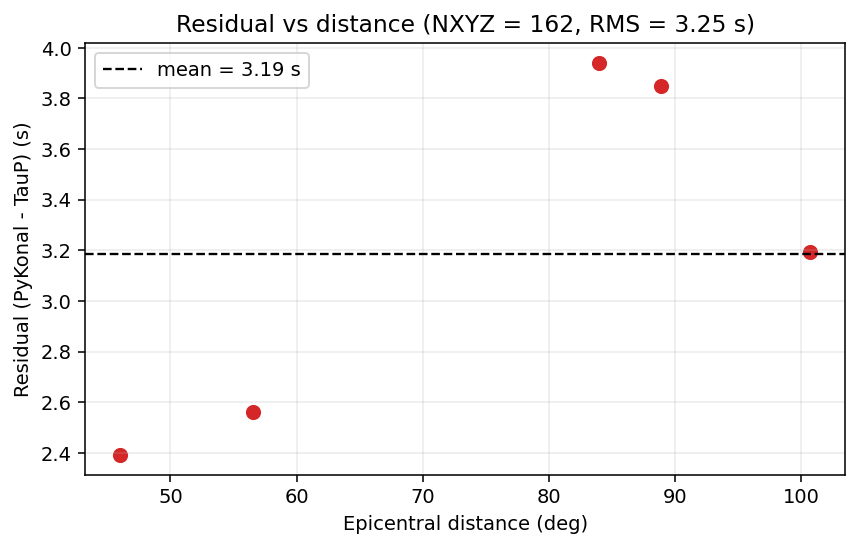

In [28]:
summary_df = results_df[["epi_deg", "taup_time_s", "travel_time_s", "delta_t_s"]].copy()
summary_df = summary_df.dropna(subset=["taup_time_s", "travel_time_s", "delta_t_s"])
summary_df["percent_error"] = 100.0 * summary_df["delta_t_s"] / summary_df["taup_time_s"]

mean_residual_s = summary_df["delta_t_s"].mean()
rms_residual_s = np.sqrt(np.mean(summary_df["delta_t_s"] ** 2))
mean_percent_error = summary_df["percent_error"].mean()

print(f"Samples compared: {len(summary_df)}")
print(f"Mean residual (PyKonal - TauP): {mean_residual_s:.3f} s")
print(f"RMS residual: {rms_residual_s:.3f} s")
print(f"Mean percent error: {mean_percent_error:.3f} %")

display(
    summary_df[["epi_deg", "delta_t_s", "percent_error"]]
    .rename(
        columns={
            "epi_deg": "Epicentral distance (deg)",
            "delta_t_s": "Residual (s)",
            "percent_error": "Percent error (%)",
        }
    )
    .round({
        "Epicentral distance (deg)": 2,
        "Residual (s)": 3,
        "Percent error (%)": 3,
    })
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)
ax.scatter(summary_df["epi_deg"], summary_df["delta_t_s"], color="tab:red", s=46)
ax.axhline(mean_residual_s, color="black", linestyle="--", linewidth=1.2, label=f"mean = {mean_residual_s:.2f} s")
ax.set_xlabel("Epicentral distance (deg)")
ax.set_ylabel("Residual (PyKonal - TauP) (s)")
ax.set_title(f"Residual vs distance (NXYZ = {NXYZ}, RMS = {rms_residual_s:.2f} s)")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


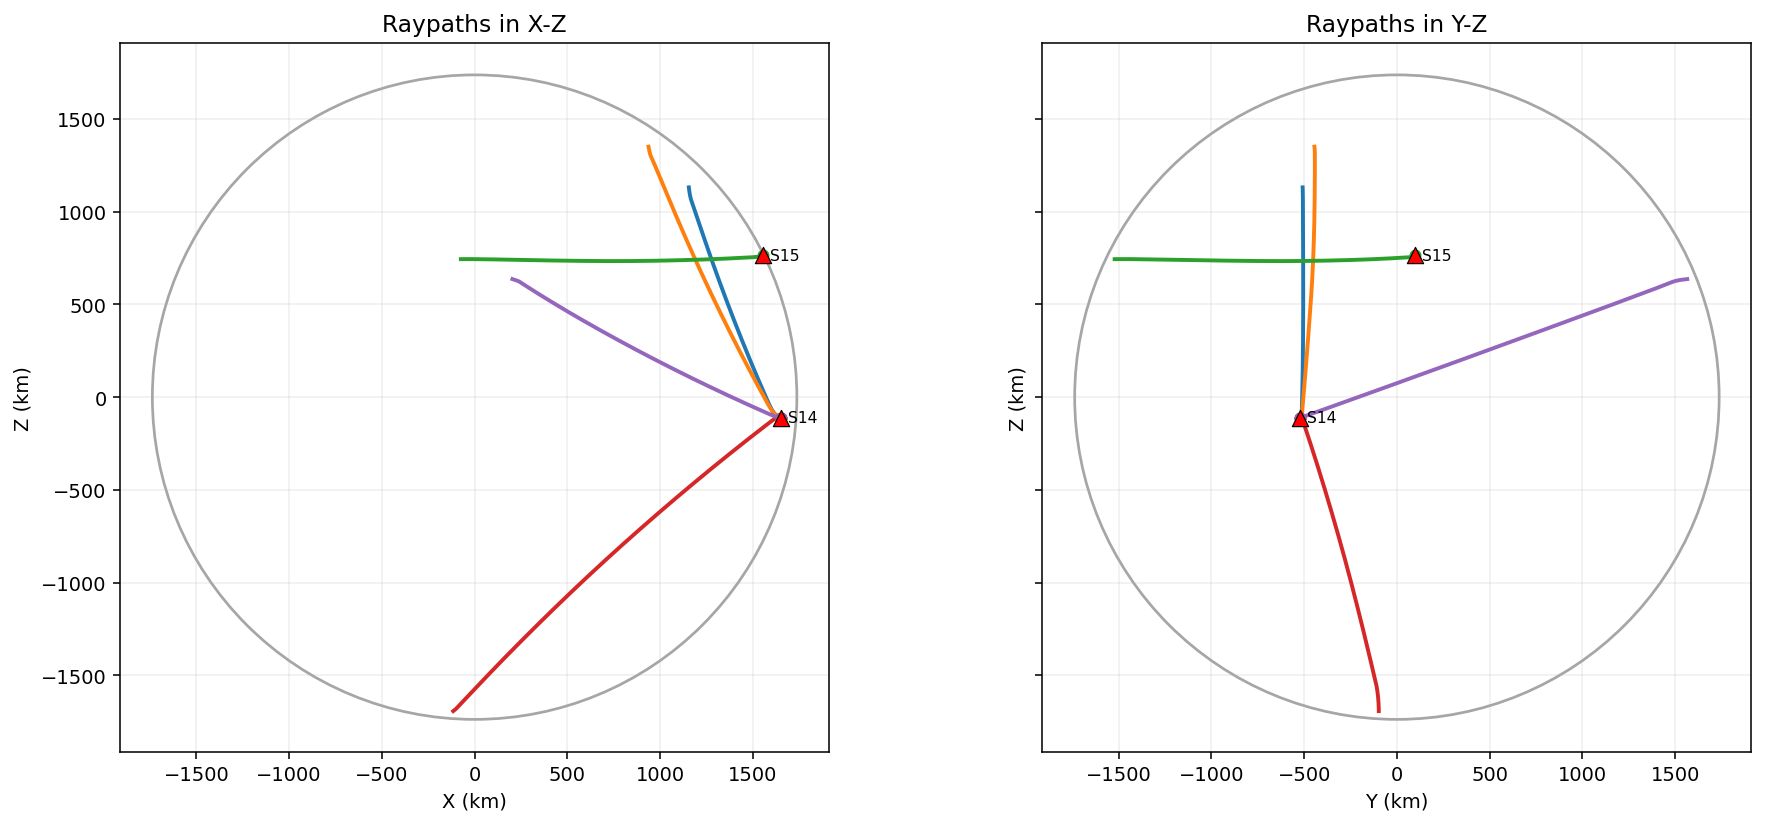

trace_stop_reason: non_decreasing_traveltime
seeded_nodes: 5
pykonal travel time: 183.887009 s
TauP reference time: 181.495526 s
travel-time difference (pykonal - TauP): 2.391484 s


,step,x_km,y_km,z_km,travel_time_s,grad_norm,source_distance
263,263,1159.564471,-507.167419,1096.150119,5.250184,0.127944,46.964056
264,264,1158.751353,-507.245612,1101.082940,4.567837,0.127991,42.109418
265,265,1158.012712,-507.337099,1106.027234,3.882711,0.128123,37.277032
266,266,1157.354134,-507.438795,1110.982628,3.196614,0.128320,32.478001
267,267,1156.777294,-507.547440,1115.948054,2.518015,0.104776,27.731882
268,268,1156.148862,-507.709870,1120.905744,1.831307,0.079574,23.087143
269,269,1155.473288,-507.937972,1125.854640,1.137581,0.054458,18.615215
270,270,1154.787107,-508.237813,1130.798247,0.442057,0.029495,14.461242


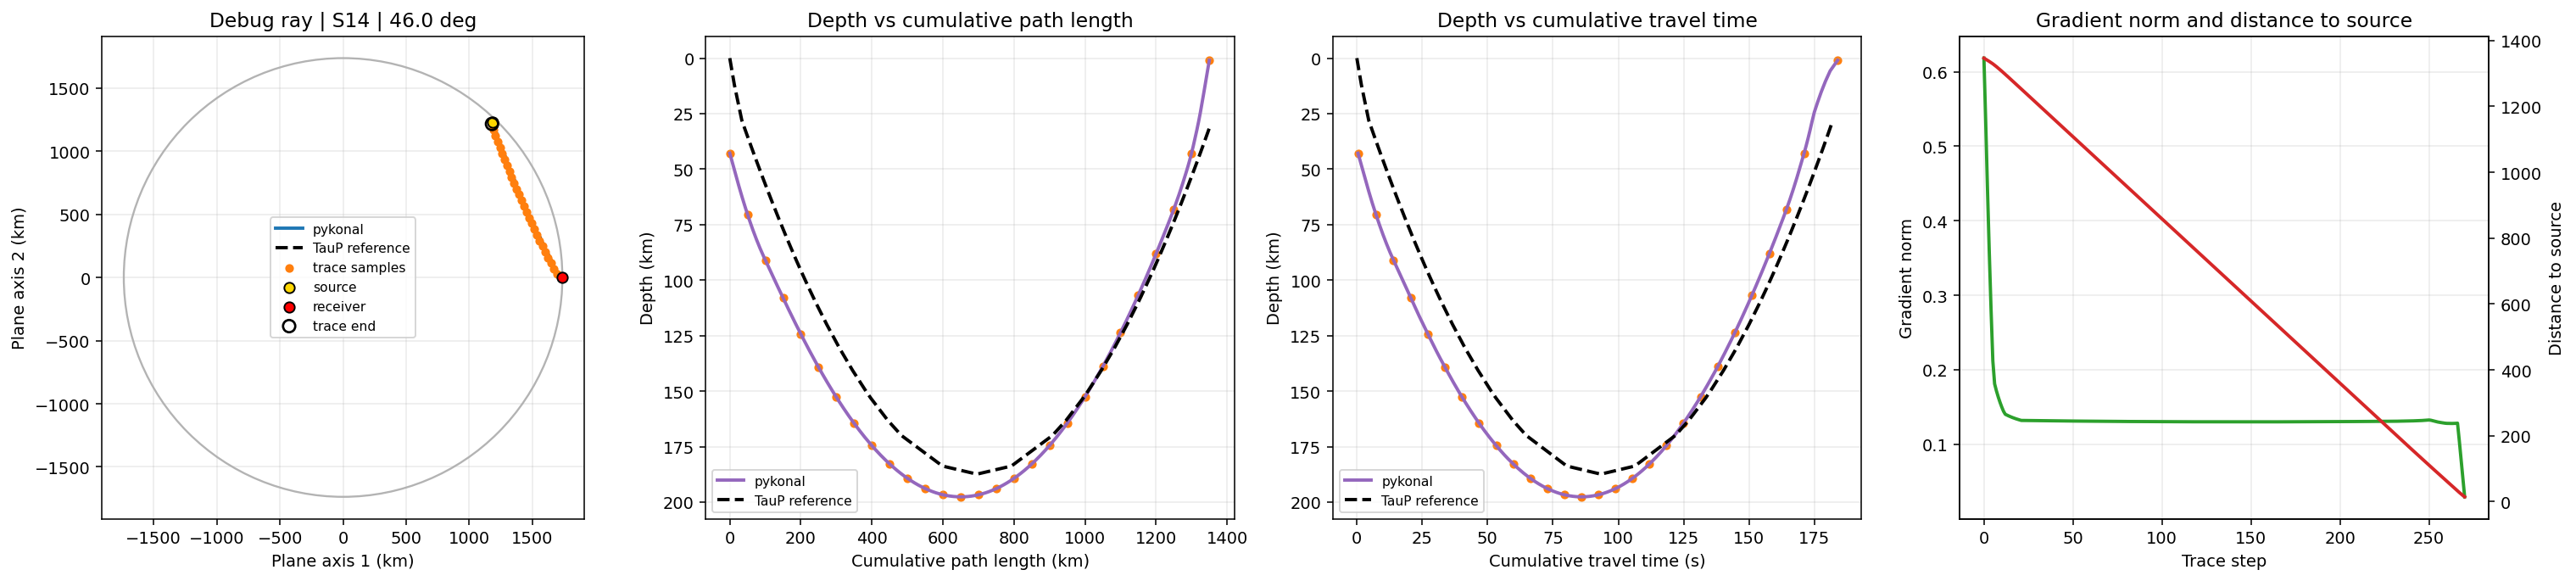

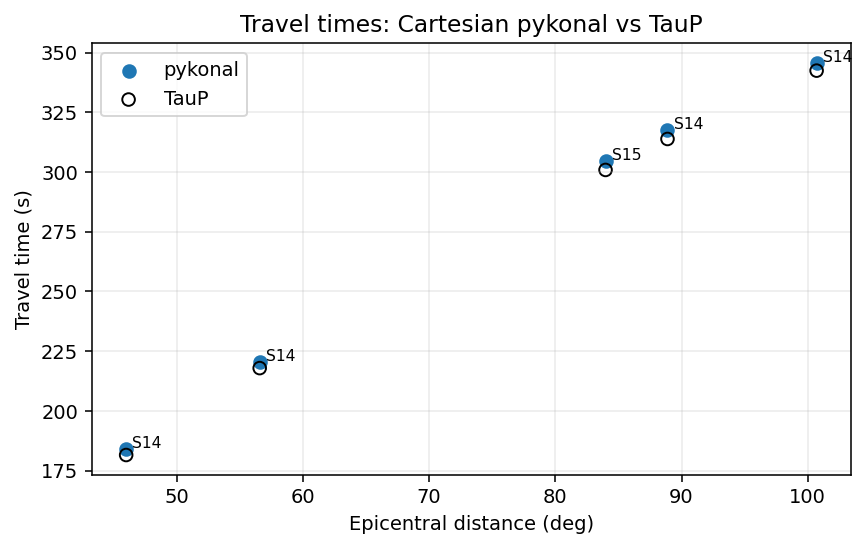

In [29]:
plot_raypaths_source_receiver_plane(solutions)
plot_single_ray_debug(solutions[DEBUG_EVENT_INDEX])

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)
ax.scatter(results_df["epi_deg"], results_df["travel_time_s"], color="tab:blue", s=42, label="pykonal")
ax.scatter(results_df["epi_deg"], results_df["taup_time_s"], facecolors="none", edgecolors="black", s=42, label="TauP")
for _, row in results_df.iterrows():
    ax.text(row["epi_deg"] + 0.5, row["travel_time_s"] + 0.5, row["station"], fontsize=8)
ax.set_xlabel("Epicentral distance (deg)")
ax.set_ylabel("Travel time (s)")
ax.set_title("Travel times: Cartesian pykonal vs TauP")
ax.grid(alpha=0.25)
ax.legend()
plt.show()
